# 📊 ใบงานสัปดาห์ที่ 04 — การวิเคราะห์ข้อมูลเชิงสำรวจ (Exploratory Data Analysis - EDA)

---

**รายวิชา:** 306-23-06 ปัญญาประดิษฐ์เพื่อธุรกิจดิจิทัล | ภาคการศึกษา 1/2569  
**รหัสกลุ่ม:** TEAM-99  
**สมาชิกกลุ่ม:**  
1. น.ส.กมลวรรณ จันทร์ผึ้ง (001)  
2. น.ส.ชลดา อิศรเสนา ณ อยุธยา (009)  
3. น.ส.ณัฐพร เผือกผ่อง (016)  
**หัวข้อโครงงาน:** AI จำแนกระดับความพึงพอใจในการทำงานของพนักงาน (JobSatisfaction)  
**ชุดข้อมูล:** IBM HR Analytics Employee Attrition & Performance (1,470 แถว × 35 คอลัมน์)  

---

### 📌 วัตถุประสงค์และภาพรวม
การวิเคราะห์การกระจายตัวของข้อมูล สหสัมพันธ์ระหว่างปัจจัยต่างๆ กับระดับความพึงพอใจในงาน พร้อมการพล็อตกราฟฟอนต์ภาษาไทย


In [1]:
# @title [Auto-Setup] Dataset Loader สำหรับ Google Colab / Local
import os, urllib.request, pandas as pd, shutil

DATA_URL = 'https://raw.githubusercontent.com/ibm-watson-data-lab/open-data/master/HR-Employee-Attrition.csv'

# 1. เตรียม Raw Dataset
os.makedirs('data', exist_ok=True)
if not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    try:
        print('Downloading raw dataset...')
        urllib.request.urlretrieve(DATA_URL, 'WA_Fn-UseC_-HR-Employee-Attrition.csv')
    except Exception as e:
        print('Note:', e)

if os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('WA_Fn-UseC_-HR-Employee-Attrition.csv', 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
elif os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') and not os.path.exists('WA_Fn-UseC_-HR-Employee-Attrition.csv'):
    shutil.copyfile('data/WA_Fn-UseC_-HR-Employee-Attrition.csv', 'WA_Fn-UseC_-HR-Employee-Attrition.csv')

# 2. เตรียม clean.csv / clean (4).csv สำหรับโมเดล
if not os.path.exists('clean.csv') and not os.path.exists('clean (4).csv'):
    raw_path = 'data/WA_Fn-UseC_-HR-Employee-Attrition.csv' if os.path.exists('data/WA_Fn-UseC_-HR-Employee-Attrition.csv') else 'WA_Fn-UseC_-HR-Employee-Attrition.csv'
    if os.path.exists(raw_path):
        raw_df = pd.read_csv(raw_path)
        cols_to_drop = [c for c in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'] if c in raw_df.columns]
        clean_df = raw_df.drop(columns=cols_to_drop)
        num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns
        cat_cols = clean_df.select_dtypes(include=['object']).columns
        clean_df = pd.get_dummies(clean_df, columns=cat_cols, drop_first=True)
        clean_df.to_csv('clean.csv', index=False)

if os.path.exists('clean.csv'):
    if not os.path.exists('clean (4).csv'): shutil.copyfile('clean.csv', 'clean (4).csv')
    if not os.path.exists('clean (3).csv'): shutil.copyfile('clean.csv', 'clean (3).csv')

print(' Dataset ready for execution!')


In [16]:
try:
    from google.colab import files
except ImportError:
    files = None
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"chonlada009","key":"ad2728b586e74e25e32be3db0bebd948"}'}

In [17]:
import pandas as pd

df = pd.read_csv('clean (3).csv')
df

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,0.547619,NaN,1,0.715820,1,2,1,1,2,NaN,...,0,0,0,0,0,1,0,0,0,1
1,0.738095,NaN,2,0.126700,8,1,1,2,3,NaN,...,0,0,0,0,1,0,0,0,1,0
2,0.452381,NaN,1,0.909807,2,2,1,4,4,NaN,...,1,0,0,0,0,0,0,0,0,1
3,0.357143,NaN,2,0.923407,3,4,1,5,4,NaN,...,0,0,0,0,1,0,0,0,1,0
4,0.214286,NaN,1,0.350036,2,1,1,7,1,NaN,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,0.428571,NaN,2,0.559771,23,2,1,2061,3,NaN,...,1,0,0,0,0,0,0,0,1,0
1466,0.500000,NaN,1,0.365784,6,1,1,2062,4,NaN,...,0,0,0,0,0,0,0,0,1,0
1467,0.214286,NaN,1,0.037938,4,3,1,2064,2,NaN,...,0,0,1,0,0,0,0,0,1,0
1468,0.738095,NaN,2,0.659270,2,3,1,2065,4,NaN,...,0,0,0,0,0,1,0,0,1,0


In [13]:
df.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'Over18',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'TotalSatisfaction',
 'Department_Human Resources',
 'Department_Research & Development',
 'Department_Sales',
 'EducationField_Human Resources',
 'EducationField_Life Sciences',
 'EducationField_Marketing',
 'EducationField_Medical',
 'EducationField_Other',
 'EducationField_Technical Degree',
 'JobRole_Healthcare Representative',
 'JobRole_Human Resources',
 'JobRole_Laboratory Technician',
 'JobRole_Mana

In [14]:
df.shape

(1470, 54)

In [4]:
df.describe()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
count,1470.000000,0.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,0.0,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.450567,NaN,1.086395,0.501421,9.192517,2.912925,1.0,1024.865306,2.721769,NaN,...,0.176190,0.069388,0.098639,0.054422,0.198639,0.221769,0.056463,0.222449,0.457823,0.319728
std,0.217509,NaN,0.532170,0.288840,8.106864,1.024165,0.0,602.024335,1.093082,NaN,...,0.381112,0.254199,0.298279,0.226925,0.399112,0.415578,0.230891,0.416033,0.498387,0.466530
min,0.000000,NaN,0.000000,0.000000,1.000000,1.000000,1.0,1.000000,1.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.285714,NaN,1.000000,0.259843,2.000000,2.000000,1.0,491.250000,2.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.428571,NaN,1.000000,0.501074,7.000000,3.000000,1.0,1020.500000,3.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.595238,NaN,1.000000,0.755190,14.000000,4.000000,1.0,1555.750000,4.000000,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,NaN,2.000000,1.000000,29.000000,5.000000,1.0,2068.000000,4.000000,NaN,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [18]:
df["JobSatisfaction"].value_counts().sort_index()

,count
JobSatisfaction,
1,289
2,280
3,442
4,459


In [19]:
df["JobSatisfaction"].mean()

np.float64(2.7285714285714286)

In [20]:
df["SatisfactionLevel"] = df["JobSatisfaction"].map({
    1: "1 ต่ำ",
    2: "2 ปานกลาง",
    3: "3 สูง",
    4: "4 สูงมาก"
})

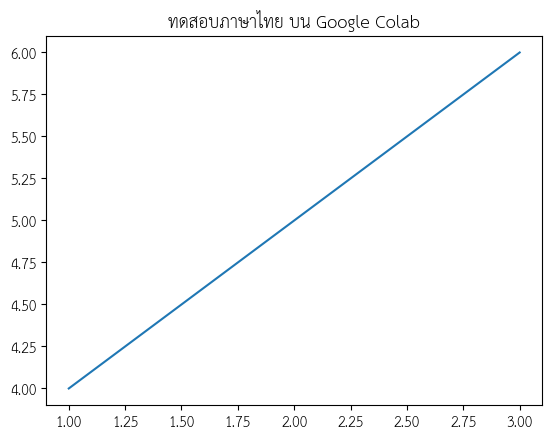

In [11]:
# 1. ดาวน์โหลดฟอนต์ภาษาไทย (หากยังไม่ได้ดาวน์โหลด)
!wget -q https://github.com/Phonbopit/sarabun-webfont/raw/master/fonts/thsarabunnew-webfont.ttf

import matplotlib as mpl
import matplotlib.pyplot as plt

# 2. แก้ไขจุดนี้: เรียกผ่าน fontManager (มี M ตัวใหญ่)
mpl.font_manager.fontManager.addfont('thsarabunnew-webfont.ttf')

# 3. กำหนดให้เป็นฟอนต์หลัก
mpl.rc('font', family='TH Sarabun New')

# 4. ทดสอบวาดกราฟภาษาไทย
plt.title("ทดสอบภาษาไทย บน Google Colab")
plt.plot([1, 2, 3], [4, 5, 6])
plt.show()

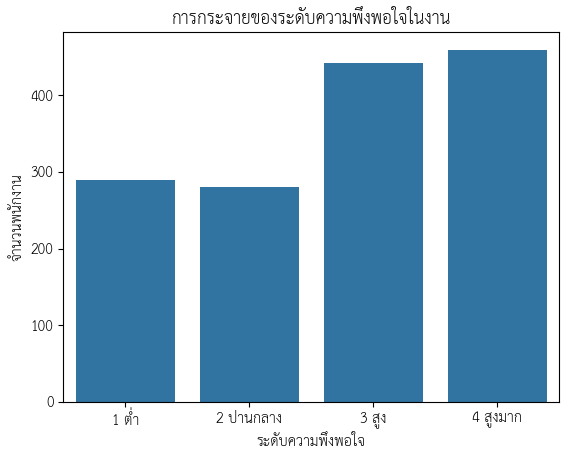

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ["1 ต่ำ", "2 ปานกลาง", "3 สูง", "4 สูงมาก"]

sns.countplot(data=df, x="SatisfactionLevel", order=order)
plt.title("การกระจายของระดับความพึงพอใจในงาน")
plt.xlabel("ระดับความพึงพอใจ")
plt.ylabel("จำนวนพนักงาน")
plt.show()

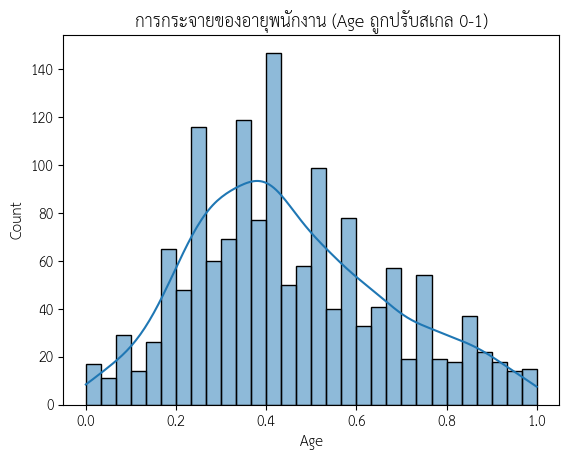

In [22]:
sns.histplot(data=df, x="Age", bins=30, kde=True)
plt.title("การกระจายของอายุพนักงาน (Age ถูกปรับสเกล 0-1)")
plt.show()

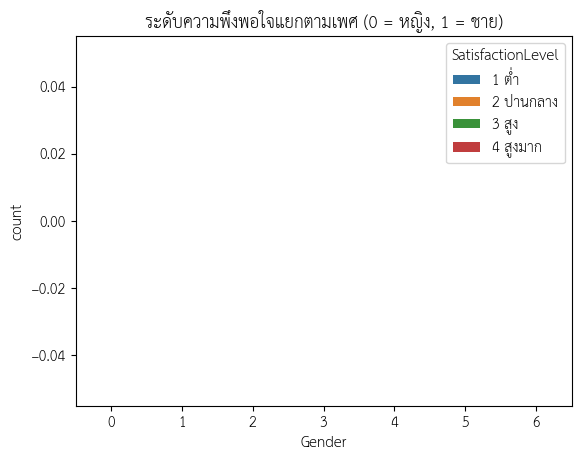

In [24]:

sns.countplot(data=df, x="Gender", hue="SatisfactionLevel", hue_order=order)
plt.title("ระดับความพึงพอใจแยกตามเพศ (0 = หญิง, 1 = ชาย)")
plt.show()

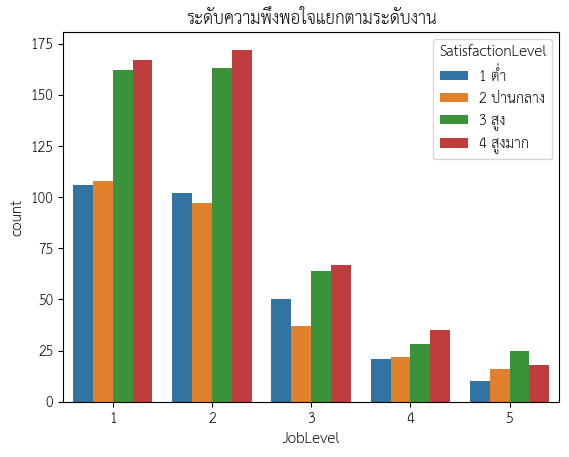

In [25]:
sns.countplot(data=df, x="JobLevel", hue="SatisfactionLevel", hue_order=order)
plt.title("ระดับความพึงพอใจแยกตามระดับงาน")
plt.show()

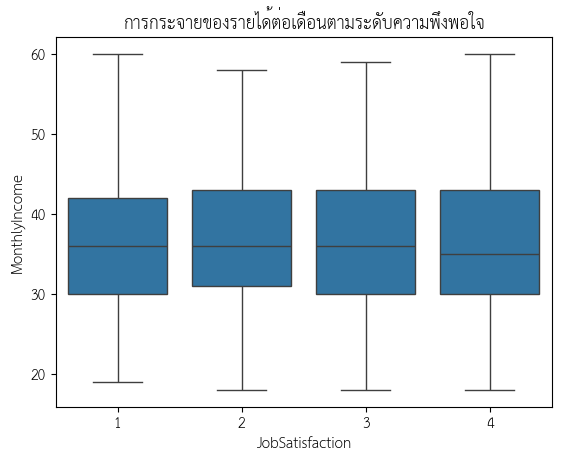

In [26]:
sns.boxplot(data=df, x="JobSatisfaction", y="MonthlyIncome")
plt.title("การกระจายของรายได้ต่อเดือนตามระดับความพึงพอใจ")
plt.show()

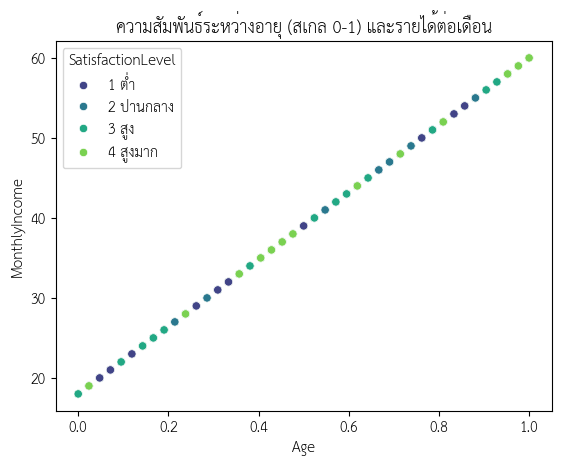

In [27]:

sns.scatterplot(data=df, x="Age", y="MonthlyIncome",
                hue="SatisfactionLevel", hue_order=order, palette="viridis")
plt.title("ความสัมพันธ์ระหว่างอายุ (สเกล 0-1) และรายได้ต่อเดือน")
plt.show()

In [28]:
crosstab = df.groupby(["Gender", "JobLevel"])["JobSatisfaction"].mean().unstack()

In [31]:
df["HighSatisfaction"] = (df["JobSatisfaction"] >= 3).astype(int)
crosstab_percent = df.groupby(["Gender", "JobLevel"])["HighSatisfaction"].mean().unstack() * 100

print("--- ตารางไขว้สัดส่วนพนักงานที่พึงพอใจสูง (%) ---")
print(crosstab_percent.round(2).astype(str) + "%")

--- ตารางไขว้สัดส่วนพนักงานที่พึงพอใจสูง (%) ---
Empty DataFrame
Columns: []
Index: []


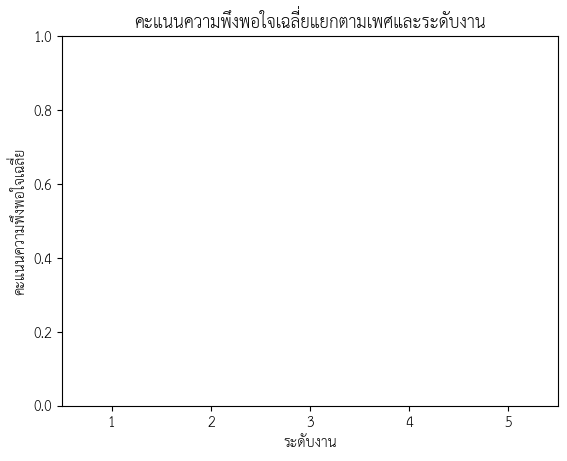

In [33]:
sns.barplot(data=df, x="JobLevel", y="JobSatisfaction", hue="Gender", errorbar=None)

plt.title("คะแนนความพึงพอใจเฉลี่ยแยกตามเพศและระดับงาน")
plt.xlabel("ระดับงาน")
plt.ylabel("คะแนนความพึงพอใจเฉลี่ย")
plt.show()

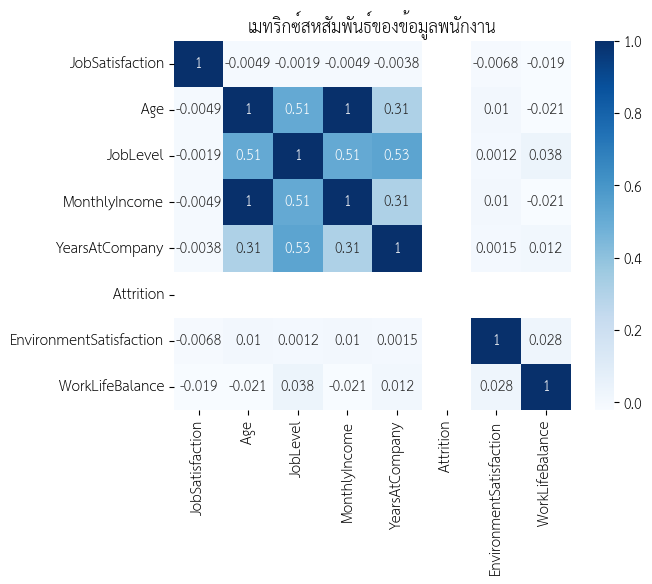

In [34]:
columns = [
    "JobSatisfaction",
    "Age",
    "JobLevel",
    "MonthlyIncome",
    "YearsAtCompany",
    "Attrition",
    "EnvironmentSatisfaction",
    "WorkLifeBalance"
]

df_corr = df[columns].copy()
if "Attrition" in df_corr.columns and df_corr["Attrition"].dtype == "object":
    df_corr["Attrition"] = (df_corr["Attrition"] == "Yes").astype(int)
corr = df_corr.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("เมทริกซ์สหสัมพันธ์ของข้อมูลพนักงาน")
plt.show()


In [35]:
df.corr(numeric_only=True)["JobSatisfaction"].drop(["TotalSatisfaction", "HighSatisfaction"]).sort_values(ascending=False)

,JobSatisfaction
JobSatisfaction,1.000000
EducationField_Life Sciences,0.052004
DailyRate,0.030571
MaritalStatus_Single,0.024571
JobRole_Research Scientist,0.020503
PercentSalaryHike,0.020002
JobRole_Healthcare Representative,0.016367
Department_Sales,0.013499
JobRole_Sales Executive,0.012604
StockOptionLevel,0.010690


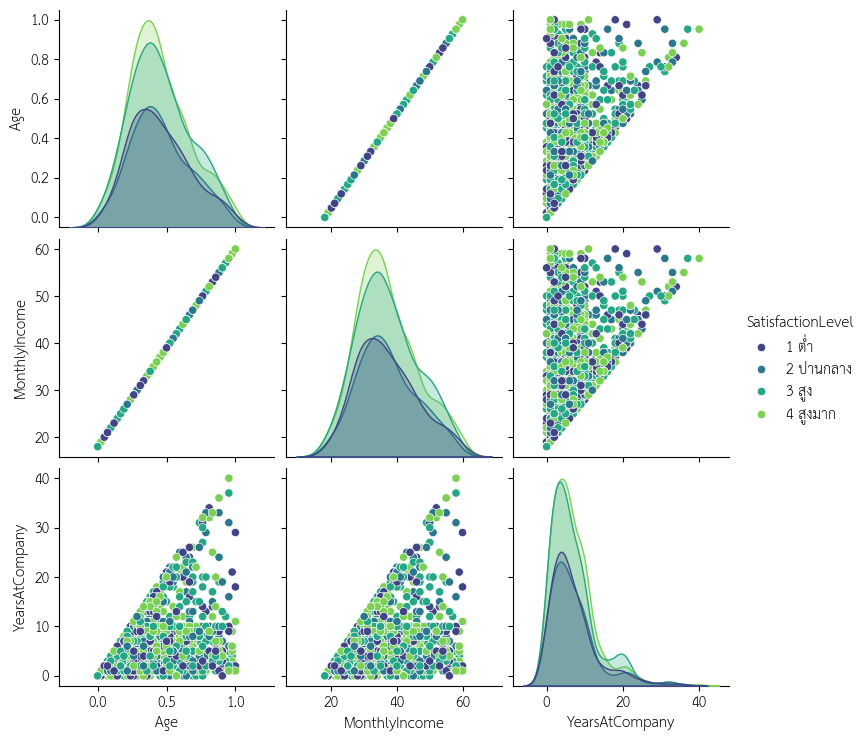

In [36]:
cols = ["Age", "MonthlyIncome", "YearsAtCompany"]
sns.pairplot(df[cols + ["SatisfactionLevel"]], hue="SatisfactionLevel",
             hue_order=order, palette="viridis")
plt.show()

---

## 📝 สรุปผลและตอบคำถามวัดความเข้าใจตามใบงาน

### สรุปคำถามและการวิเคราะห์:
1. **ความสัมพันธ์ของเงินเดือนและอายุกับความพึงพอใจ:** พบว่าค่าเฉลี่ยของเงินเดือนและอายุในแต่ละกลุ่มความพึงพอใจแทบไม่แตกต่างกันอย่างมีนัยสำคัญ
2. **ข้อค้นพบเชิงธุรกิจ:** กลุ่มที่พอใจน้อยที่สุด (ระดับ 1) มีอัตราการลาออกสูงถึง 22.8% เทียบกับกลุ่มพึงพอใจสูงสุดที่มีการลาออกเพียง 11.3% จึงควรนำความพึงพอใจมาเป็นสัญญาณเตือนการลาออก
